# Desafio Maker — Data Science Hackathon

## Objetivo

Este notebook apresenta a análise completa do desafio técnico, organizada em três missões:

1. **Data Wrangling:** identificar e tratar problemas de qualidade dos dados;
2. **Oportunidades Comerciais:** encontrar dois perfis de clientes/segmentos que apresentem alta taxa de conversão e fechamento significativamente mais rápido que a média;
3. **Fator Multiplicador:** integrar o histórico de cotações aos dados da frota para identificar um cenário de alta conversão com forte pressão de custos de manutenção e propor um mix de equipamentos mais eficiente.

A análise foi estruturada de forma sequencial, preservando os dados originais sempre que possível e documentando as decisões tomadas ao longo do processo.

# 1. Importação das bibliotecas

Nesta seção são importadas apenas as bibliotecas necessárias para leitura, tratamento, análise e visualização dos dados.

In [190]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Configuração do ambiente

Antes de iniciar a análise, algumas configurações foram definidas com a finalidade de melhorar a visualização das informações durante o decorrer do projeto.

Essas configurações não alteram a fonte original dos dados, apenas tornam a apresentação mais clara.

In [191]:
# Exibe todas as colunas dos DataFrames
pd.set_option("display.max_columns", None)

# Ajusta a quantidade máxima de linhas que aparecem
pd.set_option("display.max_rows", 100)

# Definição do tamanho padrão das figuras
plt.rcParams["figure.figsize"] = (10, 6)

# Aplica um tema padrão aos gráficos
sns.set_theme(style="whitegrid")

# 3. Carregamento dos dados

O arquivo disponibilizado contém duas abas:

- `HISTORICO_COTACOES`: histórico comercial das propostas;
- `FROTA_ATIVOS`: características financeiras e operacionais dos ativos.

As duas bases são carregadas separadamente e permanecerão independentes até a análise da Missão 3.

In [192]:
# Variável constante com o caminho do arquivo disponibilizado no desafio
CAMINHO_DADOS = Path('../data/db_atlas.xlsx')

# Carrega o histórico de cotações
historico_cotacoes = pd.read_excel(
    CAMINHO_DADOS,
    sheet_name="HISTORICO_COTACOES"
)

# Carrega as informações da frota
frota_ativos = pd.read_excel(
    CAMINHO_DADOS,
    sheet_name="FROTA_ATIVOS"
)

# Preserva o valor monetário originalmente registrado.
# Essa coluna será utilizada posteriormente na análise financeira.
historico_cotacoes["Amount_BRL_Original"] = historico_cotacoes["Amount_BRL"]

# 4. Compreendendo a base

Antes de realizar qualquer tipo de alteração, é importante compreender a estrutura das bases originalmente disponibilizadas.

Nesta parte, serão respondidos questionamentos como:
- Qual a quantidade total de registros existentes?
- Quais dados estão disponíveis?
- Quais os tipos de cada variável?
- Existem possíveis inconsistências já perceptíveis?

In [193]:
print(
    f"Histórico de cotações: "
    f"{historico_cotacoes.shape[0]} registros e "
    f"{historico_cotacoes.shape[1]} colunas"
)

print(
    f"Frota de ativos: "
    f"{frota_ativos.shape[0]} registros e "
    f"{frota_ativos.shape[1]} colunas"
)

display(historico_cotacoes.head())
display(frota_ativos.head())

Histórico de cotações: 6000 registros e 9 colunas
Frota de ativos: 580 registros e 6 colunas


,Client_Name,Quote_Date,Quote_ID,Close_Date,Days_To_Close,Serial_ID,Amount_BRL,Stage,Amount_BRL_Original
0,Rosberg Energy 429,2023-09-05 00:27:21,QT-100000,2023-10-12 00:27:21,NaN,SN-10144,42865.48,Perdido,42865.48
1,Mansell Agro 996,2023-08-22 07:54:37,QT-100001,2023-10-03 07:54:37,42.0,SN-10253,42139.31,Perdido,42139.31
2,Verstappen Logistics 715,2023-07-28 09:59:33,QT-100002,2023-07-29 09:59:33,1.0,SN-10130,44611.83,Ganho,44611.83
3,Clark Dynamics 461,2023-09-12 08:33:55,QT-100003,2023-10-23 08:33:55,41.0,SN-10249,39920.19,Perdido,39920.19
4,Stewart Agro 422,06/02/2024,QT-100004,2024-03-15 07:46:46,38.0,SN-10463,26830.45,Ganho,26830.45


,Serial_ID,F1_Model,Solution_Type,Acquisition_Cost_BRL,Accumulated_Depreciation_BRL,Total_Maintenance_Cost_BRL
0,SN-10000,MP4/4,Solução 1,237454.01,223825.85,246761.35
1,SN-10001,MP4/4,Solução 1,259865.85,213974.27,180242.10
2,SN-10002,MP4/4,Solução 1,205808.36,191386.63,197713.71
3,SN-10003,MP4/4,Solução 1,270807.26,217481.97,320079.53
4,SN-10004,MP4/4,Solução 1,283244.26,235616.99,200847.09


In [194]:
historico_cotacoes.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Client_Name          6000 non-null   str           
 1   Quote_Date           6000 non-null   object        
 2   Quote_ID             6000 non-null   str           
 3   Close_Date           6000 non-null   datetime64[us]
 4   Days_To_Close        5682 non-null   float64       
 5   Serial_ID            6000 non-null   str           
 6   Amount_BRL           6000 non-null   float64       
 7   Stage                6000 non-null   str           
 8   Amount_BRL_Original  6000 non-null   float64       
dtypes: datetime64[us](1), float64(3), object(1), str(4)
memory usage: 422.0+ KB


In [195]:
frota_ativos.info()

<class 'pandas.DataFrame'>
RangeIndex: 580 entries, 0 to 579
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Serial_ID                     580 non-null    str    
 1   F1_Model                      580 non-null    str    
 2   Solution_Type                 580 non-null    str    
 3   Acquisition_Cost_BRL          580 non-null    float64
 4   Accumulated_Depreciation_BRL  580 non-null    float64
 5   Total_Maintenance_Cost_BRL    580 non-null    float64
dtypes: float64(3), str(3)
memory usage: 27.3 KB


# 5. Avaliação da qualidade dos dados

Esta etapa busca encontrar possíveis problemas que possam comprometer a confiabilidade das análises futuras.

Serão avaliados os seguintes aspectos:
- Valores ausentes;
- Registros duplicados;
- Tipos de dados;
- Estatísticas descritivas;
- Valores únicos em variáveis categóricas;
- Consistência entre os registros.

## 5.1 Verificação de valores ausentes
Valores ausentes podem destacar falhas no processo de coleta, integração ou armazenamento dos dados.

Nesta seção, será identificado o número absoluto e o percentual de valores nulos em cada coluna de ambas as bases.


In [196]:
def analisar_valores_ausentes(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Retorna a quantidade e o percentual de valores ausentes por coluna.
    """

    valores_ausentes = dataframe.isna().sum()

    percentual_ausentes = (
        dataframe.isna().mean() * 100
    ).round(2)

    resultado = pd.DataFrame({
        "Valores ausentes": valores_ausentes,
        "Percentual (%)": percentual_ausentes
    })

    return resultado.sort_values(
        by="Percentual (%)",
        ascending=False
    )

In [197]:
display(analisar_valores_ausentes(historico_cotacoes))
display(analisar_valores_ausentes(frota_ativos))

,Valores ausentes,Percentual (%)
Days_To_Close,318,5.3
Client_Name,0,0.0
Quote_Date,0,0.0
Quote_ID,0,0.0
Close_Date,0,0.0
Serial_ID,0,0.0
Amount_BRL,0,0.0
Stage,0,0.0
Amount_BRL_Original,0,0.0


,Valores ausentes,Percentual (%)
Serial_ID,0,0.0
F1_Model,0,0.0
Solution_Type,0,0.0
Acquisition_Cost_BRL,0,0.0
Accumulated_Depreciation_BRL,0,0.0
Total_Maintenance_Cost_BRL,0,0.0


### Interpretação

A única ausência relevante no histórico ocorre em `Days_To_Close`, com 318 registros sem preenchimento (5,3% da base).  
A base de frota não apresenta valores ausentes.

Como `Days_To_Close` pode ser derivado das datas da proposta e do fechamento, sua recuperação será investigada antes de qualquer remoção de registros.

## 5.2 Verificação de registros duplicados

In [198]:
print(
    f"Duplicados no histórico: "
    f"{historico_cotacoes.duplicated().sum()}"
)

print(
    f"Duplicados na frota: "
    f"{frota_ativos.duplicated().sum()}"
)

Duplicados no histórico: 0
Duplicados na frota: 0


### Interpretação

Não foram identificados registros completamente duplicados em nenhuma das duas bases.

## 5.3 Estatísticas descritivas

As estatísticas descritivas permitem compreender a distribuição das variáveis numéricas.

Serão analisados indicadores como média, desvio padrão, valores mínimos, máximos e quartis.

In [199]:
display(historico_cotacoes.describe().T)
display(frota_ativos.describe().T)

,count,mean,min,25%,50%,75%,max,std
Close_Date,6000,2025-02-10 21:55:27.385166,2023-07-25 09:33:19,2024-05-12 19:20:57.250000,2025-02-13 06:57:05,2025-11-11 18:36:38.500000,2026-10-30 01:17:20,NaN
Days_To_Close,5682.0,24.831749,0.0,6.0,20.0,37.0,174.0,22.269995
Amount_BRL,6000.0,50419.1581,-144294.072538,19447.56,30783.225,42134.1875,9999999.99,407679.091778
Amount_BRL_Original,6000.0,50419.1581,-144294.072538,19447.56,30783.225,42134.1875,9999999.99,407679.091778


,count,mean,std,min,25%,50%,75%,max
Acquisition_Cost_BRL,580.0,173038.975552,54566.271942,100756.29,133873.8725,162772.925,192085.395,349005.39
Accumulated_Depreciation_BRL,580.0,85666.261552,49299.568321,15016.24,56048.8925,72847.080,95120.050,278623.92
Total_Maintenance_Cost_BRL,580.0,53369.216914,57659.842276,3126.50,23298.6150,36942.415,54170.320,320079.53


### Interpretação

A variável `Amount_BRL` apresenta valores extremos, incluindo registros negativos e valores muito superiores à distribuição principal.

Esses registros serão tratados estatisticamente para as análises exploratórias, mas o valor monetário original permanecerá preservado na coluna `Amount_BRL_Original` para evitar distorções na análise financeira da Missão 3.

## 5.4 Concistência da variável `Stage`

Antes de realizar agrupamentos, é importante compreender os valores existentes nas variáveis categóricas.

Essa análise permite identificar categorias inconsistentes e possíveis problemas de padronização.

In [200]:
historico_cotacoes["Stage"].value_counts(dropna=False)

Stage
Perdido     2882
Ganho       2216
Perdido      137
ganho        135
lost         133
 WON         128
GAnho        125
W0n          123
 Not Won     121
Name: count, dtype: int64

### Interpretação

A coluna apresenta diferentes representações para apenas dois estados de negócio: **Ganho** e **Perdido**.

Foram observadas diferenças de idioma, capitalização, espaços excedentes e erros de digitação. Essa inconsistência precisa ser corrigida antes do cálculo do Win Rate.

# 6. Limpeza e estruturação dos dados — Missão 1

A limpeza será aplicada apenas após a investigação das inconsistências.

Os tratamentos realizados serão:

1. padronização das datas;
2. recuperação de `Days_To_Close`;
3. padronização de `Stage`;
4. criação de uma versão tratada de `Amount_BRL` para análises estatísticas.

## 6.1 Conversão das datas e recuperação de `Days_To_Close`

`Quote_Date` foi carregada como texto enquanto `Close_Date` já estava em formato temporal.

A conversão é necessária para validar e recuperar os valores ausentes de `Days_To_Close`.

In [201]:
# Converte a data da proposta. A base utiliza dia antes do mês
# nos registros textuais.
historico_cotacoes["Quote_Date"] = pd.to_datetime(
    historico_cotacoes["Quote_Date"],
    dayfirst=True
)

# Calcula o intervalo entre abertura e fechamento da proposta.
dias_calculados = (
    historico_cotacoes["Close_Date"]
    - historico_cotacoes["Quote_Date"]
).dt.days

# Preenche apenas os registros originalmente ausentes.
historico_cotacoes["Days_To_Close"] = (
    historico_cotacoes["Days_To_Close"]
    .fillna(dias_calculados)
    .astype(int)
)

In [202]:
print(
    f"Valores ausentes em Days_To_Close: "
    f"{historico_cotacoes['Days_To_Close'].isna().sum()}"
)

historico_cotacoes[
    ["Quote_Date", "Close_Date", "Days_To_Close"]
].head()

Valores ausentes em Days_To_Close: 0


,Quote_Date,Close_Date,Days_To_Close
0,2023-09-05 00:27:21,2023-10-12 00:27:21,37
1,2023-08-22 07:54:37,2023-10-03 07:54:37,42
2,2023-07-28 09:59:33,2023-07-29 09:59:33,1
3,2023-09-12 08:33:55,2023-10-23 08:33:55,41
4,2024-02-06 00:00:00,2024-03-15 07:46:46,38


### Resultado

Os 318 valores ausentes foram recuperados utilizando a diferença entre `Close_Date` e `Quote_Date`, sem necessidade de excluir observações ou realizar imputações artificiais.

## 6.2 Padronização da coluna `Stage`

In [203]:
# Normaliza espaços e capitalização antes da aplicação
# das regras de equivalência.
stage_normalizado = (
    historico_cotacoes["Stage"]
    .str.strip()
    .str.lower()
)

MAPEAMENTO_STAGE = {
    "ganho": "Ganho",
    "won": "Ganho",
    "w0n": "Ganho",
    "perdido": "Perdido",
    "lost": "Perdido",
    "not won": "Perdido",
}

historico_cotacoes["Stage"] = (
    stage_normalizado
    .replace(MAPEAMENTO_STAGE)
)

In [204]:
historico_cotacoes["Stage"].value_counts()

Stage
Perdido    3273
Ganho      2727
Name: count, dtype: int64

### Resultado

As nove representações originalmente encontradas foram consolidadas em duas categorias consistentes:

- `Ganho`;
- `Perdido`.

Isso garante que o Win Rate seja calculado corretamente.

In [205]:
# A padronização será realizada em três etapas:
# 1. Remover espaços em branco no início e no final dos textos;
# 2. Uniformizar a capitalização para facilitar a comparação entre valores;
# 3. Mapear todas as representações equivalentes para apenas duas categorias: "Ganho" e "Perdido".

# Remove espaços em branco excedentes
historico_cotacoes["Stage"] = historico_cotacoes["Stage"].str.strip()

# Padroniza a escrita para letras minúsculas
historico_cotacoes["Stage"] = historico_cotacoes["Stage"].str.lower()

# Mapeia todas as variações para uma representação única
MAPEAMENTO_STAGE = {
    "ganho": "Ganho",
    "won": "Ganho",
    "w0n": "Ganho",
    "perdido": "Perdido",
    "lost": "Perdido",
    "not won": "Perdido",
}

historico_cotacoes["Stage"] = historico_cotacoes["Stage"].replace(MAPEAMENTO_STAGE)

## 6.3 Tratamento estatístico dos outliers de `Amount_BRL`

Os valores monetários extremos podem distorcer médias, gráficos e análises baseadas em faixas.

Foi utilizada Winsorização baseada no Intervalo Interquartil (IQR).  
Para preservar a informação financeira original, o tratamento será aplicado em uma **nova coluna**, sem sobrescrever `Amount_BRL_Original`.

In [206]:
q1 = historico_cotacoes["Amount_BRL"].quantile(0.25)
q3 = historico_cotacoes["Amount_BRL"].quantile(0.75)

iqr = q3 - q1

limite_inferior = q1 - (1.5 * iqr)
limite_superior = q3 + (1.5 * iqr)

historico_cotacoes["Amount_BRL_Tratado"] = (
    historico_cotacoes["Amount_BRL"]
    .clip(
        lower=limite_inferior,
        upper=limite_superior
    )
)

print(f"Limite inferior: R$ {limite_inferior:,.2f}")
print(f"Limite superior: R$ {limite_superior:,.2f}")

Limite inferior: R$ -14,582.38
Limite superior: R$ 76,164.13


### Observação metodológica

A Winsorização é utilizada apenas para reduzir a influência dos extremos nas análises estatísticas.

Os valores financeiros originalmente registrados continuam disponíveis em `Amount_BRL_Original` e serão utilizados na análise econômica da Missão 3.

# 7. Validação da limpeza

Após as transformações, os principais pontos são verificados novamente antes de iniciar as análises de negócio.

In [207]:
print("Tipos das datas:")
print(
    historico_cotacoes[
        ["Quote_Date", "Close_Date"]
    ].dtypes
)

print("\nValores ausentes:")
print(
    historico_cotacoes[
        ["Days_To_Close", "Stage"]
    ].isna().sum()
)

print("\nCategorias de Stage:")
print(
    historico_cotacoes["Stage"].value_counts()
)

print("\nResumo de Amount_BRL_Tratado:")
display(
    historico_cotacoes["Amount_BRL_Tratado"]
    .describe()
)

Tipos das datas:
Quote_Date    datetime64[us]
Close_Date    datetime64[us]
dtype: object

Valores ausentes:
Days_To_Close    0
Stage            0
dtype: int64

Categorias de Stage:
Stage
Perdido    3273
Ganho      2727
Name: count, dtype: int64

Resumo de Amount_BRL_Tratado:


count     6000.000000
mean     31755.149357
std      19206.999644
min     -14582.381250
25%      19447.560000
50%      30783.225000
75%      42134.187500
max      76164.128750
Name: Amount_BRL_Tratado, dtype: float64

# 8. Identificação das oportunidades comerciais — Missão 2

A Diretoria suspeita da existência de dois perfis de clientes ou segmentos que apresentem simultaneamente:

- **Win Rate muito superior à média**;
- **tempo de fechamento significativamente inferior à média**.

A análise desta missão utiliza exclusivamente `HISTORICO_COTACOES`.

## 8.1 Benchmark geral da operação

Antes de identificar oportunidades, são calculados os indicadores gerais que servirão como referência.

In [208]:
total_propostas = historico_cotacoes["Quote_ID"].nunique()
total_clientes = historico_cotacoes["Client_Name"].nunique()

tempo_medio_geral = (
    historico_cotacoes["Days_To_Close"].mean()
)

win_rate_geral = (
    historico_cotacoes["Stage"]
    .eq("Ganho")
    .mean()
    * 100
)

print(f"Total de propostas: {total_propostas}")
print(f"Total de clientes: {total_clientes}")
print(f"Tempo médio geral: {tempo_medio_geral:.2f} dias")
print(f"Win Rate geral: {win_rate_geral:.2f}%")

Total de propostas: 6000
Total de clientes: 3415
Tempo médio geral: 24.95 dias
Win Rate geral: 45.45%


### Benchmark encontrado

A operação apresenta:

- **6.000 propostas**;
- **Win Rate geral de 45,45%**;
- **tempo médio de fechamento de 24,95 dias**.

Esses valores serão utilizados como referência para avaliar os perfis identificados.

## 8.2 Construção do segmento do cliente

Os nomes seguem o padrão:

`Nome + Segmento + Identificador`

Como `Heavy Machining` possui duas palavras, o segmento é obtido removendo o primeiro e o último elemento do nome, em vez de selecionar uma posição fixa.

In [209]:
def extrair_segmento(nome_cliente: str) -> str:
    """Extrai o segmento presente entre o nome e o identificador do cliente."""

    partes = nome_cliente.split()

    return " ".join(partes[1:-1])


historico_cotacoes["Segmento"] = (
    historico_cotacoes["Client_Name"]
    .apply(extrair_segmento)
)

historico_cotacoes[
    ["Client_Name", "Segmento"]
].sample(
    10,
    random_state=42
)

,Client_Name,Segmento
1782,Raikkonen Energy 870,Energy
3917,Alonso Industries 99,Industries
221,Hakkinen Logistics 937,Logistics
2135,Verstappen Corp 536,Corp
5224,Perez Aero 201,Aero
1168,Leclerc Industries 677,Industries
879,Rosberg Aero 283,Aero
156,Piquet Energy 537,Energy
1657,Sainz Energy 269,Energy
323,Hakkinen Heavy Machining 536,Heavy Machining


## 8.3 Desempenho por segmento

In [210]:
analise_segmentos = (
    historico_cotacoes
    .groupby("Segmento")
    .agg(
        Quantidade_Propostas=("Quote_ID", "count"),
        Tempo_Medio_Dias=("Days_To_Close", "mean"),
        Win_Rate=("Stage", lambda x: (x == "Ganho").mean() * 100)
    )
    .round(2)
    .sort_values(
        by=["Win_Rate", "Tempo_Medio_Dias"],
        ascending=[False, True]
    )
)

analise_segmentos

,Quantidade_Propostas,Tempo_Medio_Dias,Win_Rate
Segmento,,,
Logistics,788,2.05,82.11
Heavy Machining,681,28.35,67.55
Agro,758,27.78,37.20
Energy,765,28.73,36.86
Aero,763,30.23,36.57
Corp,741,27.07,36.17
Dynamics,722,27.89,33.93
Industries,782,28.76,33.76


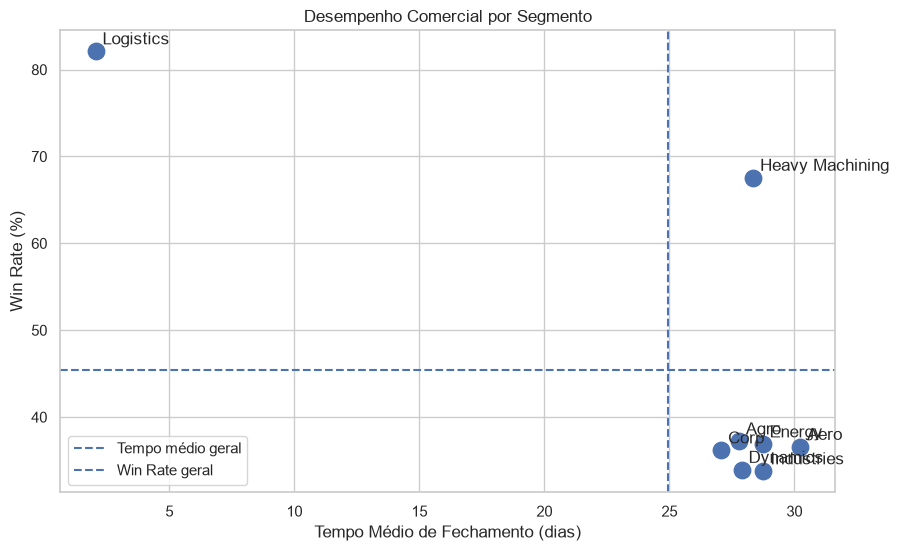

In [211]:
plt.figure(figsize=(10, 6))

plt.scatter(
    analise_segmentos["Tempo_Medio_Dias"],
    analise_segmentos["Win_Rate"],
    s=140
)

for segmento, linha in analise_segmentos.iterrows():
    plt.annotate(
        segmento,
        (
            linha["Tempo_Medio_Dias"],
            linha["Win_Rate"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.axvline(
    tempo_medio_geral,
    linestyle="--",
    label="Tempo médio geral"
)

plt.axhline(
    win_rate_geral,
    linestyle="--",
    label="Win Rate geral"
)

plt.title("Desempenho Comercial por Segmento")
plt.xlabel("Tempo Médio de Fechamento (dias)")
plt.ylabel("Win Rate (%)")
plt.legend()
plt.show()

### Oportunidade 1 — Segmento Logistics

O segmento `Logistics` se destaca de forma inequívoca:

- **788 propostas**;
- **82,11% de Win Rate**;
- **2,05 dias de tempo médio de fechamento**.

Comparado à operação geral:

- o Win Rate é 36,66 pontos percentuais superior;
- o ciclo médio de fechamento é aproximadamente 22,9 dias menor.

O elevado volume de observações reforça que se trata de um padrão recorrente e não de um resultado isolado.

## 8.4 Desempenho individual dos clientes

Para procurar uma segunda oportunidade distinta de `Logistics`, os clientes são avaliados individualmente.

Como existem milhares de clientes com poucas propostas, serão considerados apenas aqueles com **pelo menos 10 propostas**, reduzindo a influência de casos com amostra muito pequena.

In [212]:
analise_clientes = (
    historico_cotacoes
    .groupby("Client_Name")
    .agg(
        Quantidade_Propostas=("Quote_ID", "count"),
        Tempo_Medio_Dias=("Days_To_Close", "mean"),
        Win_Rate=("Stage", lambda x: (x == "Ganho").mean() * 100)
    )
    .round(2)
)

segmento_cliente = (
    historico_cotacoes[
        ["Client_Name", "Segmento"]
    ]
    .drop_duplicates()
)

clientes_relevantes = (
    analise_clientes[
        analise_clientes["Quantidade_Propostas"] >= 10
    ]
    .reset_index()
    .merge(
        segmento_cliente,
        on="Client_Name",
        how="left"
    )
)

clientes_candidatos = (
    clientes_relevantes[
        (clientes_relevantes["Win_Rate"] > win_rate_geral) &
        (clientes_relevantes["Tempo_Medio_Dias"] < tempo_medio_geral)
    ]
    .sort_values(
        by=["Win_Rate", "Tempo_Medio_Dias"],
        ascending=[False, True]
    )
)

clientes_candidatos

,Client_Name,Quantidade_Propostas,Tempo_Medio_Dias,Win_Rate,Segmento
28,Rosberg Logistics 121,11,2.64,90.91,Logistics
32,Senna Heavy Machining 614,10,3.70,90.00,Heavy Machining
18,Piquet Logistics 200,11,2.36,81.82,Logistics
16,Leclerc Logistics 616,10,2.20,80.00,Logistics
23,Raikkonen Logistics 461,10,2.30,80.00,Logistics
31,Senna Aero 671,10,2.80,80.00,Aero
33,Senna Industries 496,13,2.62,69.23,Industries
37,Vettel Logistics 976,10,2.00,60.00,Logistics
20,Raikkonen Agro 107,10,23.10,60.00,Agro
12,Hamilton Agro 895,10,19.50,50.00,Agro


## 8.5 Segunda oportunidade fora de Logistics

Como `Logistics` já representa a primeira oportunidade em nível de segmento, são avaliados separadamente os clientes de alto desempenho pertencentes aos demais segmentos.

In [213]:
segunda_oportunidade_candidatos = (
    clientes_candidatos[
        clientes_candidatos["Segmento"] != "Logistics"
    ]
    .sort_values(
        by=["Win_Rate", "Tempo_Medio_Dias"],
        ascending=[False, True]
    )
)

segunda_oportunidade_candidatos

,Client_Name,Quantidade_Propostas,Tempo_Medio_Dias,Win_Rate,Segmento
32,Senna Heavy Machining 614,10,3.70,90.00,Heavy Machining
31,Senna Aero 671,10,2.80,80.00,Aero
33,Senna Industries 496,13,2.62,69.23,Industries
20,Raikkonen Agro 107,10,23.10,60.00,Agro
12,Hamilton Agro 895,10,19.50,50.00,Agro


### Oportunidade 2 — Senna Heavy Machining 614

O cliente `Senna Heavy Machining 614` apresenta:

- **10 propostas**;
- **90,00% de Win Rate**;
- **3,70 dias de tempo médio de fechamento**.

Em comparação com a operação geral:

- Win Rate: **90,00% vs. 45,45%**;
- tempo médio: **3,70 vs. 24,95 dias**.

O resultado caracteriza uma oportunidade individual de alta conversão e ciclo comercial curto.

Apesar do excelente desempenho, o volume é muito inferior ao observado no segmento `Logistics`. Portanto, essa oportunidade deve ser interpretada como um sinal comercial forte, porém com menor evidência estatística.

## 8.6 Resposta à Missão 2

As duas oportunidades identificadas são:

### 1. Segmento Logistics
- 788 propostas;
- Win Rate de **82,11%**;
- fechamento médio em **2,05 dias**.

### 2. Cliente Senna Heavy Machining 614
- 10 propostas;
- Win Rate de **90,00%**;
- fechamento médio em **3,70 dias**.

Ambos apresentam desempenho muito superior aos benchmarks gerais de **45,45% de Win Rate** e **24,95 dias de fechamento médio**.

# 9. Fator Multiplicador — Missão 3 (Opcional)

A Missão 2 identificou `Senna Heavy Machining 614` como uma oportunidade comercial relevante.

Nesta etapa, essa conclusão será reavaliada incorporando os dados da frota.

A pergunta passa a ser:

> Uma oportunidade com alta conversão continua sendo economicamente atrativa quando os custos de manutenção dos equipamentos são considerados?

## 9.1 Validação da chave de integração

As duas bases se relacionam por `Serial_ID`.

Antes do `merge`, é necessário validar a granularidade da chave.

In [214]:
print(f"Registros na frota: {len(frota_ativos)}")
print(
    f"Serial_ID únicos na frota: "
    f"{frota_ativos['Serial_ID'].nunique()}"
)

print(
    f"Serial_ID únicos no histórico: "
    f"{historico_cotacoes['Serial_ID'].nunique()}"
)

Registros na frota: 580
Serial_ID únicos na frota: 580
Serial_ID únicos no histórico: 1436


A frota possui **580 registros e 580 `Serial_ID` únicos**, indicando um registro por ativo.

O histórico possui múltiplas propostas para diferentes equipamentos. Portanto, a relação esperada é do tipo **muitos-para-um** (`many_to_one`): várias propostas podem apontar para um ativo da frota.

## 9.2 Cobertura dos dados da frota

In [215]:
serial_historico = set(
    historico_cotacoes["Serial_ID"]
)

serial_frota = set(
    frota_ativos["Serial_ID"]
)

serial_com_frota = (
    serial_historico
    .intersection(serial_frota)
)

cotacoes_com_frota = historico_cotacoes[
    historico_cotacoes["Serial_ID"].isin(serial_frota)
]

cobertura_ativos = (
    len(serial_com_frota)
    / len(serial_historico)
    * 100
)

cobertura_cotacoes = (
    len(cotacoes_com_frota)
    / len(historico_cotacoes)
    * 100
)

print(
    f"Ativos encontrados nas duas bases: "
    f"{len(serial_com_frota)}"
)

print(
    f"Cobertura dos ativos: "
    f"{cobertura_ativos:.2f}%"
)

print(
    f"Cotações com dados de frota: "
    f"{len(cotacoes_com_frota)}"
)

print(
    f"Cobertura das cotações: "
    f"{cobertura_cotacoes:.2f}%"
)

Ativos encontrados nas duas bases: 580
Cobertura dos ativos: 40.39%
Cotações com dados de frota: 4290
Cobertura das cotações: 71.50%


### Cobertura encontrada

- **580 dos 1.436 ativos distintos** do histórico possuem informações de frota: 40,39%;
- esses ativos representam **4.290 das 6.000 propostas**: 71,50%.

A análise financeira será restrita às propostas para as quais existem informações de frota.

## 9.3 Integração das bases

In [216]:
base_integrada = historico_cotacoes.merge(
    frota_ativos,
    on="Serial_ID",
    how="inner",
    validate="many_to_one"
)

print(
    f"Registros da base integrada: "
    f"{len(base_integrada)}"
)

Registros da base integrada: 4290


## 9.4 Reavaliação do cliente Senna Heavy Machining 614

In [217]:
CLIENTE_ALVO = "Senna Heavy Machining 614"

dados_cliente = base_integrada[
    base_integrada["Client_Name"] == CLIENTE_ALVO
].copy()

win_rate_cliente_integrado = (
    dados_cliente["Stage"]
    .eq("Ganho")
    .mean()
    * 100
)

print(
    f"Propostas com dados de frota: "
    f"{dados_cliente['Quote_ID'].nunique()}"
)

print(
    f"Ativos distintos: "
    f"{dados_cliente['Serial_ID'].nunique()}"
)

print(
    f"Win Rate na base integrada: "
    f"{win_rate_cliente_integrado:.2f}%"
)

Propostas com dados de frota: 8
Ativos distintos: 8
Win Rate na base integrada: 87.50%


Mesmo após a restrição às propostas com dados de frota, o cliente mantém **87,50% de Win Rate**, confirmando que o elevado desempenho comercial continua presente.

## 9.5 Mix atual de equipamentos do cliente

In [218]:
mix_atual_cliente = (
    dados_cliente[
        [
            "Quote_ID",
            "Serial_ID",
            "F1_Model",
            "Solution_Type",
            "Amount_BRL_Original",
            "Stage",
            "Total_Maintenance_Cost_BRL",
            "Acquisition_Cost_BRL",
            "Accumulated_Depreciation_BRL"
        ]
    ]
    .sort_values(
        by="Total_Maintenance_Cost_BRL",
        ascending=False
    )
)

mix_atual_cliente

,Quote_ID,Serial_ID,F1_Model,Solution_Type,Amount_BRL_Original,Stage,Total_Maintenance_Cost_BRL,Acquisition_Cost_BRL,Accumulated_Depreciation_BRL
4232,QT-105929,SN-10017,MP4/4,Solução 1,91928.625479,Ganho,315503.85,277513.28,261119.14
3410,QT-104758,SN-10046,MP4/4,Solução 1,111647.765421,Ganho,278309.91,236362.96,223544.36
3544,QT-104949,SN-10013,MP4/4,Solução 1,102655.426170,Ganho,218907.58,244015.25,199679.08
3127,QT-104350,SN-10021,MP4/4,Solução 1,101744.376166,Ganho,218145.25,235675.33,198471.67
2937,QT-104083,SN-10008,MP4/4,Solução 1,148125.326463,Ganho,176788.97,245607.00,225412.31
3701,QT-105174,SN-10007,MP4/4,Solução 1,140536.803162,Ganho,175399.37,213949.39,180535.13
3241,QT-104519,SN-10093,AMR23,Solução 2,41800.050000,Ganho,7751.64,329579.27,60478.06
4205,QT-105891,SN-10071,W14,Solução 2,39126.680000,Perdido,5309.59,272426.93,42723.87


A composição disponível para o cliente apresenta forte concentração no modelo `MP4/4`, pertencente à `Solução 1`.

## 9.6 Comparação dos modelos

Para evitar que o mesmo custo de manutenção seja contabilizado repetidamente, a manutenção será somada uma única vez por `Serial_ID`.

A métrica `Contribuicao_Aproximada` é utilizada apenas como **proxy comparativa**, pois a base não contém todos os elementos necessários para o cálculo contábil do lucro líquido.

In [219]:
def calcular_indicadores_modelo(grupo: pd.DataFrame) -> pd.Series:
    """Calcula indicadores comerciais e financeiros aproximados por modelo."""

    propostas_ganhas = grupo[
        grupo["Stage"] == "Ganho"
    ]

    ativos_unicos = (
        grupo
        .drop_duplicates(
            subset="Serial_ID"
        )
    )

    valor_propostas_ganhas = (
        propostas_ganhas[
            "Amount_BRL_Original"
        ]
        .sum()
    )

    manutencao_total = (
        ativos_unicos[
            "Total_Maintenance_Cost_BRL"
        ]
        .sum()
    )

    contribuicao_aproximada = (
        valor_propostas_ganhas
        - manutencao_total
    )

    razao_manutencao_receita = (
        manutencao_total / valor_propostas_ganhas
        if valor_propostas_ganhas > 0
        else np.nan
    )

    return pd.Series({
        "Propostas": grupo["Quote_ID"].nunique(),
        "Ativos": grupo["Serial_ID"].nunique(),
        "Win_Rate": grupo["Stage"].eq("Ganho").mean() * 100,
        "Valor_Propostas_Ganhas": valor_propostas_ganhas,
        "Manutencao_Total": manutencao_total,
        "Contribuicao_Aproximada": contribuicao_aproximada,
        "Razao_Manutencao_Receita": razao_manutencao_receita
    })


rentabilidade_modelos = (
    dados_cliente
    .groupby(
        ["Solution_Type", "F1_Model"]
    )
    .apply(
        calcular_indicadores_modelo,
        include_groups=False
    )
    .round(2)
)

rentabilidade_modelos

Propostas  Ativos  Win_Rate  Valor_Propostas_Ganhas  \
Solution_Type F1_Model                                                        
Solução 1     MP4/4           6.0     6.0     100.0               696638.32   
Solução 2     AMR23           1.0     1.0     100.0                41800.05   
              W14             1.0     1.0       0.0                    0.00   

                        Manutencao_Total  Contribuicao_Aproximada  \
Solution_Type F1_Model                                              
Solução 1     MP4/4           1383054.93               -686416.61   
Solução 2     AMR23              7751.64                 34048.41   
              W14                5309.59                 -5309.59   

                        Razao_Manutencao_Receita  
Solution_Type F1_Model                            
Solução 1     MP4/4                         1.99  
Solução 2     AMR23                         0.19  
              W14                            NaN

### Resultado

Para as propostas do cliente com dados de frota:

| Modelo | Propostas | Win Rate | Valor das propostas ganhas | Manutenção acumulada | Contribuição aproximada |
|---|---:|---:|---:|---:|---:|
| MP4/4 | 6 | 100% | ~R$ 696,6 mil | ~R$ 1,383 milhão | ~-R$ 686,4 mil |
| AMR23 | 1 | 100% | ~R$ 41,8 mil | ~R$ 7,8 mil | ~R$ 34,0 mil |
| W14 | 1 | 0% | R$ 0 | ~R$ 5,3 mil | ~-R$ 5,3 mil |

O `MP4/4` apresenta excelente conversão, porém sua manutenção acumulada é aproximadamente **1,99 vez** o valor das propostas ganhas associadas aos ativos analisados.

O `AMR23` apresentou conversão positiva com custo de manutenção muito inferior.

> **Importante:** a contribuição aproximada não representa lucro líquido contábil. O custo de manutenção é acumulado ao longo da vida do ativo e a base não disponibiliza todos os custos, receitas históricas, impostos ou períodos de uso necessários para calcular rentabilidade líquida real.

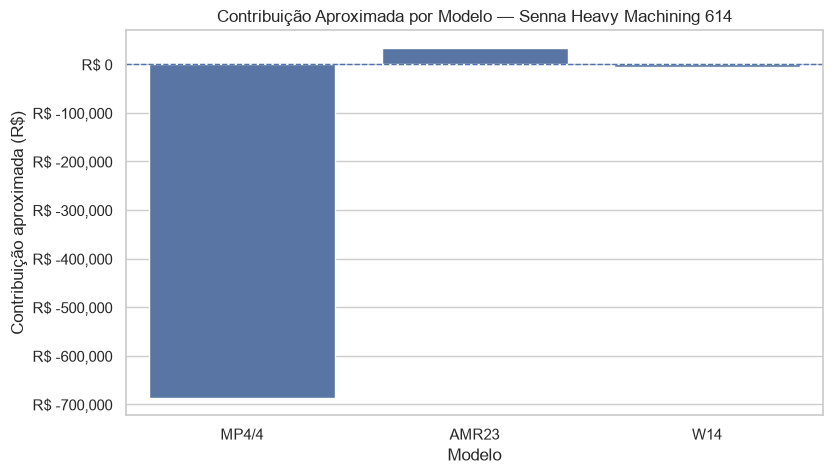

In [220]:
resultado_plot = (
    rentabilidade_modelos
    .reset_index()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=resultado_plot,
    x="F1_Model",
    y="Contribuicao_Aproximada"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Contribuição Aproximada por Modelo — Senna Heavy Machining 614"
)
plt.xlabel("Modelo")
plt.ylabel("Contribuição aproximada (R$)")

plt.gca().yaxis.set_major_formatter((lambda valor, _: f"R$ {valor:,.0f}"))

plt.show()

## 9.7 Recomendação do mix

Os dados indicam que o problema não está na capacidade do cliente de converter propostas, mas na **concentração em um modelo com alto custo acumulado de manutenção**.

### Recomendação

- **Reduzir gradualmente a concentração no `MP4/4`**: o modelo possui excelente conversão, mas apresenta forte pressão de manutenção;
- **Aumentar de forma controlada a participação do `AMR23`**: o modelo já apresentou conversão positiva para o cliente e possui custo de manutenção significativamente inferior;
- **Não priorizar o `W14` neste momento**: apesar do baixo custo de manutenção, a única proposta observada foi perdida.

Não é recomendado definir percentuais rígidos de mix com a amostra disponível. O `AMR23` possui apenas uma observação para esse cliente, portanto a mudança deve ser incremental e monitorada em novas propostas.

# 10. Conclusões Gerais

## Missão 1 — Data Wrangling

A base apresentou problemas reais de qualidade:

- 318 valores ausentes em `Days_To_Close`;
- inconsistência de tipo em `Quote_Date`;
- nove representações diferentes para `Stage`;
- valores extremos em `Amount_BRL`.

Os valores ausentes de `Days_To_Close` foram recuperados a partir das datas, `Stage` foi padronizado e uma versão Winsorizada de `Amount_BRL` foi criada para análises estatísticas, preservando os valores financeiros originais.

---

## Missão 2 — Duas Oportunidades Comerciais

### Segmento Logistics
- **788 propostas**;
- **82,11% de Win Rate**;
- **2,05 dias de fechamento médio**.

### Senna Heavy Machining 614
- **10 propostas**;
- **90,00% de Win Rate**;
- **3,70 dias de fechamento médio**.

Ambos apresentam desempenho muito superior à média geral de **45,45% de Win Rate** e **24,95 dias de fechamento**.

`Logistics` possui evidência muito mais robusta devido ao grande volume de propostas. `Senna Heavy Machining 614` representa uma oportunidade individual promissora, porém com uma amostra menor.

---

## Missão 3 — Fator Multiplicador

Ao incorporar os dados da frota, `Senna Heavy Machining 614` continua apresentando alta conversão (**87,50%** nas propostas com cobertura de frota), porém seu mix está concentrado no `MP4/4`.

O `MP4/4` apresenta 100% de conversão nas seis propostas observadas, mas os ativos associados acumulam aproximadamente **R$ 1,383 milhão em manutenção**, frente a aproximadamente **R$ 696,6 mil em propostas ganhas**.

O `AMR23` também apresentou conversão positiva para o cliente, com custo de manutenção substancialmente inferior.

### Estratégia sugerida

Realizar um **rebalanceamento gradual do mix**, reduzindo a exposição ao `MP4/4` e aumentando experimentalmente a participação do `AMR23`.

A recomendação deve ser monitorada conforme novos dados sejam gerados, pois a amostra do `AMR23` para esse cliente ainda é pequena.

---

## Limitações

- apenas 71,50% das propostas possuem informações correspondentes na base de frota;
- os custos de manutenção são acumulados por ativo e não necessariamente referentes exclusivamente à proposta analisada;
- a base não contém todos os elementos necessários para o cálculo do lucro líquido contábil.

Portanto, os indicadores financeiros da Missão 3 devem ser interpretados como **evidências direcionais para tomada de decisão**, e não como demonstrações contábeis de rentabilidade.